In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, TimeSeriesSplit, cross_val_predict,RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay, average_precision_score

import kagglehub
import math
import os
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split

## Loading dataset from Kaggle

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [3]:
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
df.shape

(284807, 31)

# DATA UNDERSTANDING

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1081)

In [4]:
df_cleaned = df.drop_duplicates().copy()

**Dataset has no empty data point while has 1081 duplicate rows and all of these were drop**

In [11]:
df_cleaned.shape

(283726, 31)

In [12]:
df_cleaned.head(35)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


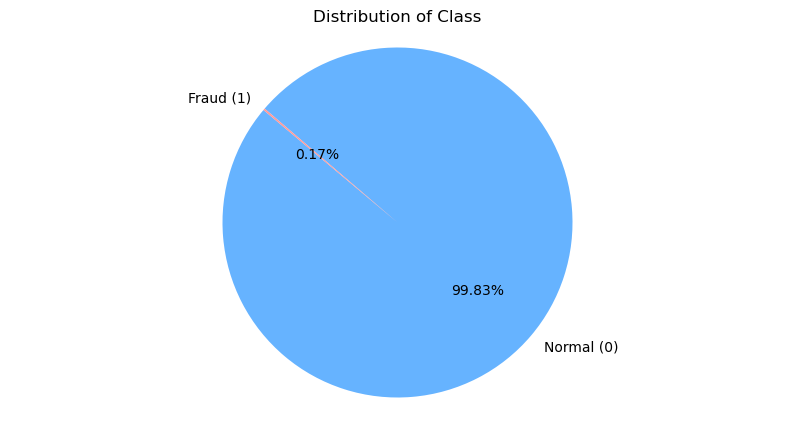

In [13]:
plt.figure(figsize=(10, 5))

fraud_counts = df_cleaned['Class'].value_counts().sort_index()

labels = ['Normal (0)', 'Fraud (1)']
colors = ['#66b3ff', '#ff9999']

plt.pie(fraud_counts,
        labels=labels,
        autopct='%1.2f%%',
        startangle=140,
        colors=colors)

plt.title('Distribution of Class', fontsize=12)
plt.axis('equal')  # makes the pie chart circular

plt.show()

**Observation:** All 29 features are unique and numeric. The last feature is the target feature representing the fraud transaction by 1 and the legitimate transaction by 0. The target class is extreme imbalance while the non-fraud transaction take over 99% of the total amount of transactions

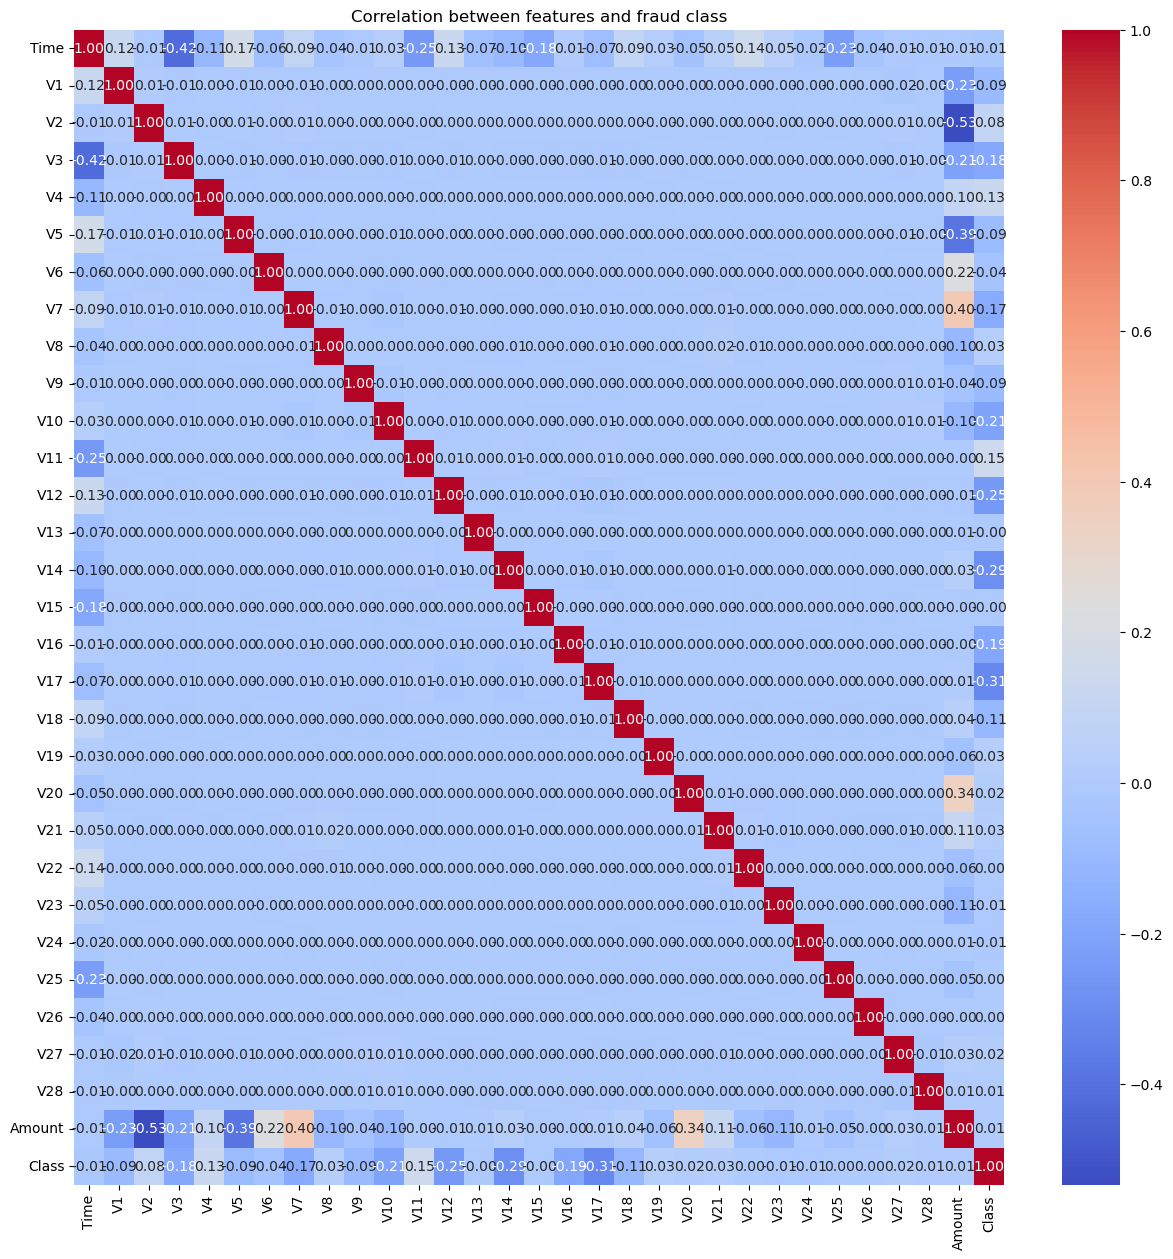

In [14]:
plt.figure(figsize=(15, 15)) 
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between features and fraud class')
plt.show()

**Observation:** No correlation between features 

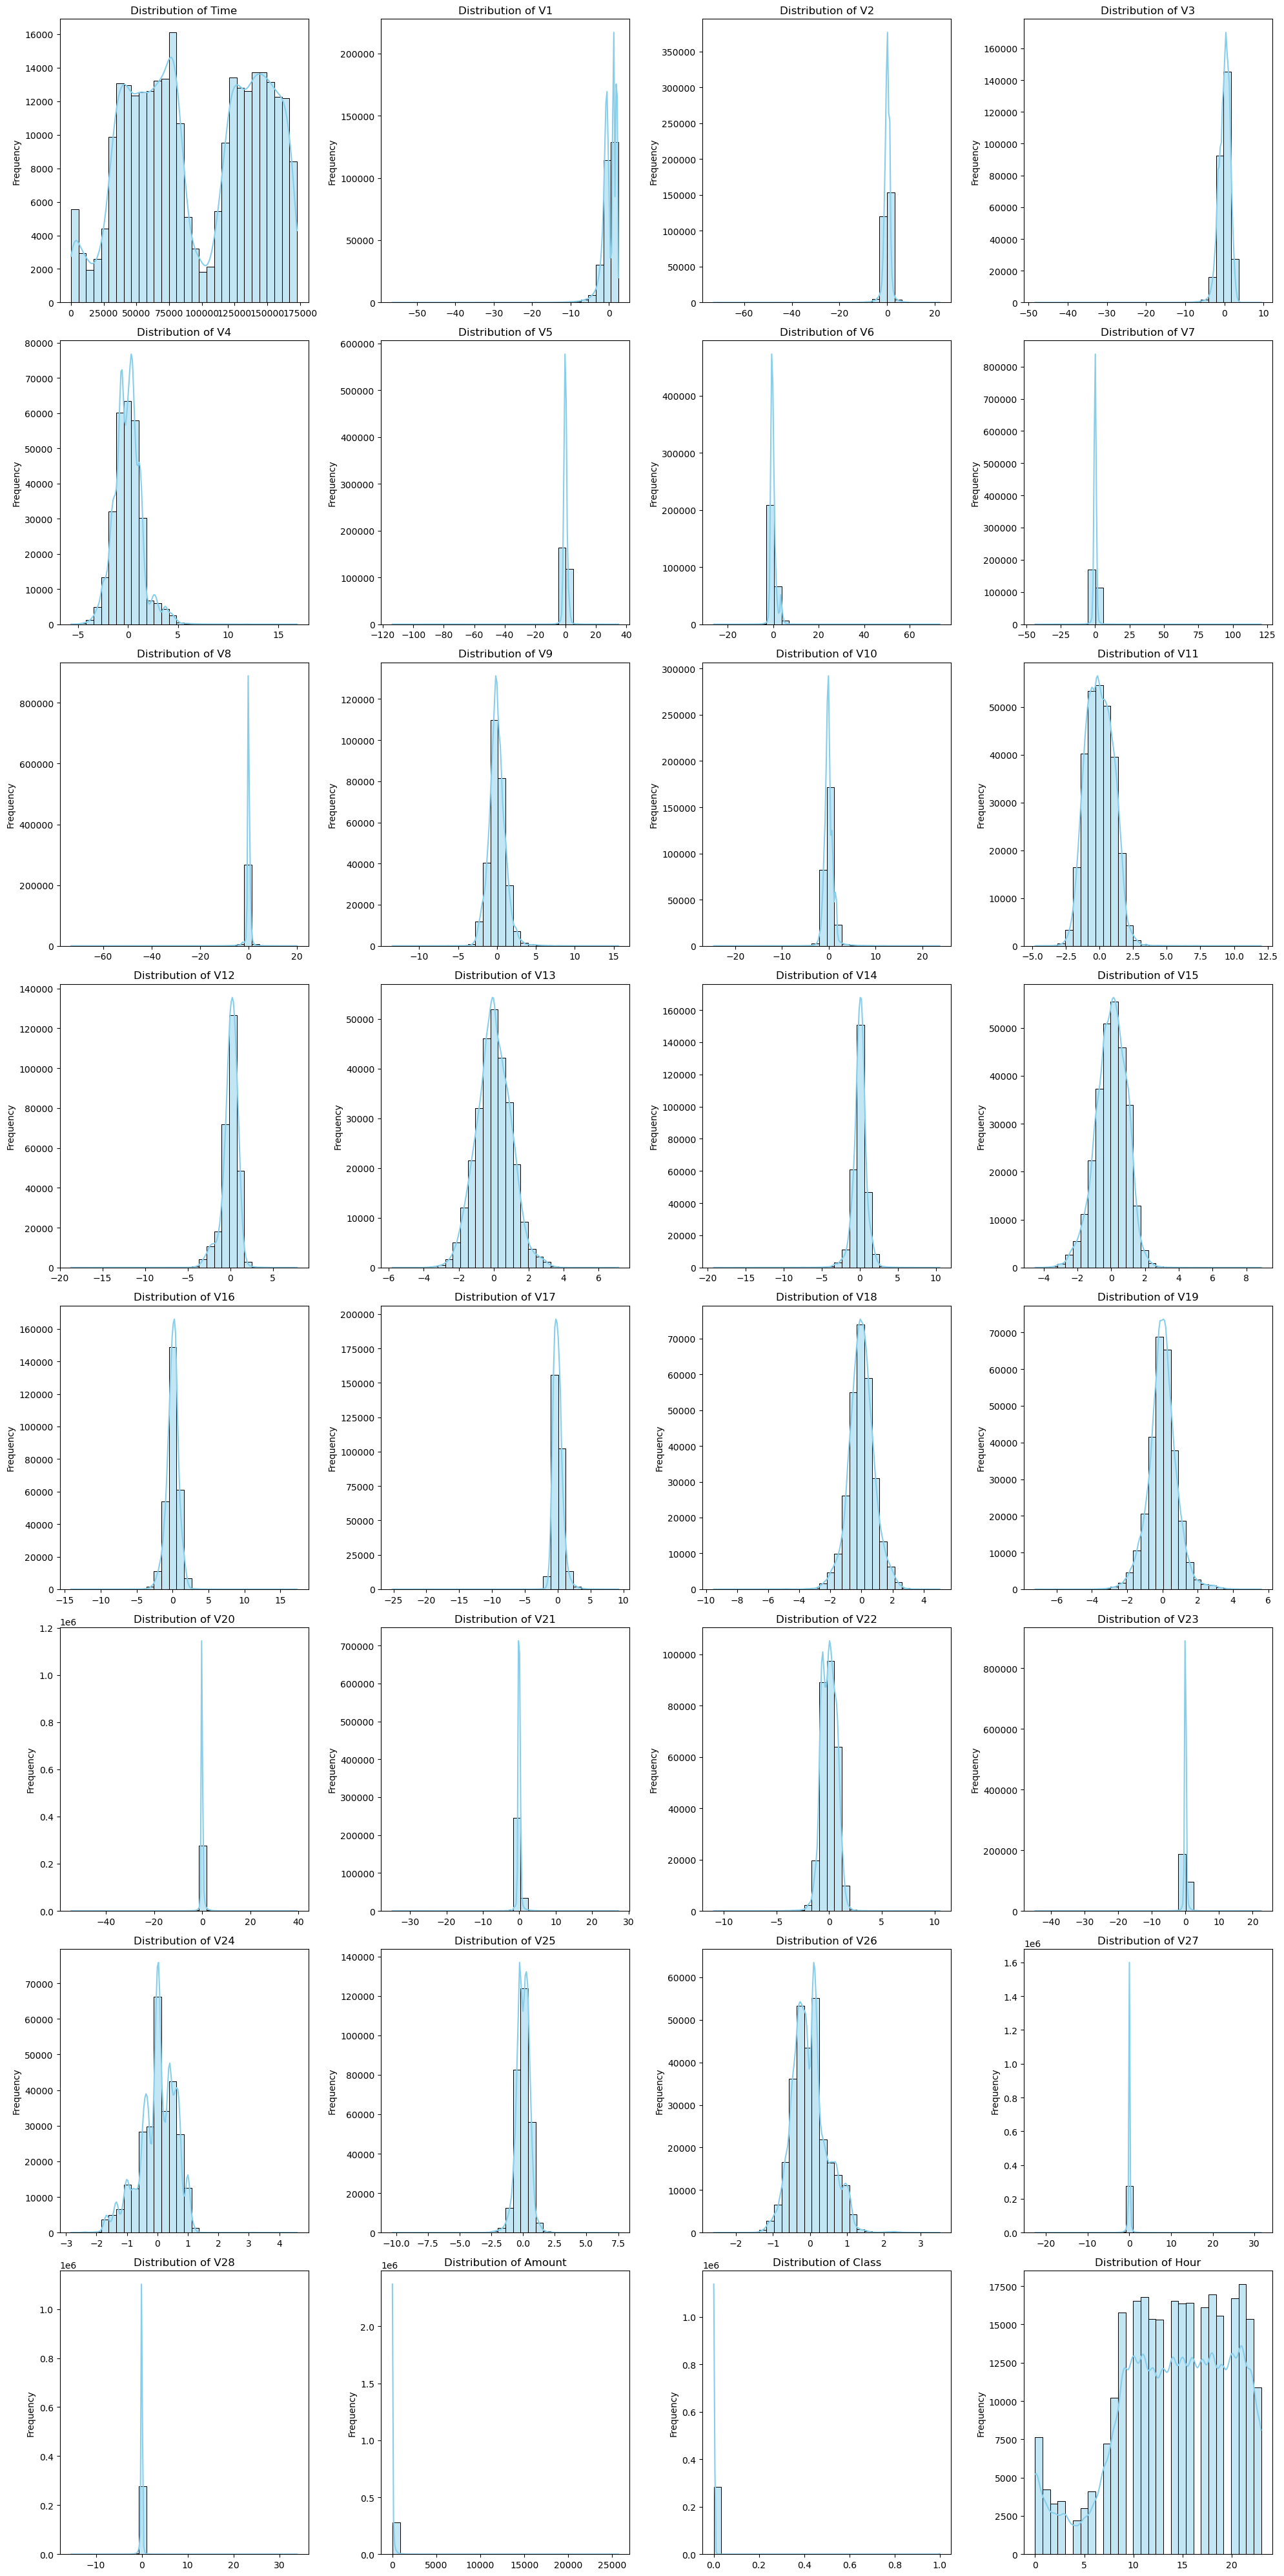

In [13]:
n_cols = 4
df_ncols = df_cleaned.select_dtypes(include='number').columns
n_rows = math.ceil(len(df_ncols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(df_ncols):
    sns.histplot(df_cleaned[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for j in range(len(df_ncols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight') 
plt.show()

**Observation:** While the PCA features are centered at 0, they exhibit significant skewness and long-tailed distributions, suggesting that standard scaling alone is insufficient and further transformation is required. Similarly, the Amount feature is heavily right-skewed and dispersed across a wide range, highlighting the need for robust scaling or power transformations to stabilize the variance.

In [14]:
df_fraud = df_cleaned[df_cleaned['Class'] == 1]
df_safe = df_cleaned[df_cleaned['Class'] == 0]
def cal_outliers_not_fraud(df, column):
    if (column in df.columns) :        
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75) 
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        return outliers
    else:
        print(f"column '{column}' is not in data frame")
        return None

In [15]:
outlier_dfs_dict = {} 
outlier_rates = {}    

for col in df_ncols:
    outliers = cal_outliers_not_fraud(df_cleaned, col)
    
    if outliers is not None:
        outlier_dfs_dict[col] = outliers
        
        # 2. Calculate the outlier percentage %
        rate = (len(outliers) / len(df_safe)) * 100
        outlier_rates[col] = rate

status_df = pd.DataFrame.from_dict(outlier_rates, orient='index', columns=['Outlier Rate'])
print(status_df)

        Outlier Rate
Time        0.000000
V1          2.452931
V2          4.727223
V3          1.167154
V4          3.916640
V5          4.314517
V6          8.079703
V7          3.120532
V8          8.439099
V9          2.894585
V10         3.299171
V11         0.259485
V12         5.395177
V13         1.186925
V14         4.963760
V15         1.018171
V16         2.887878
V17         2.595912
V18         2.636512
V19         3.583369
V20         9.727346
V21         5.084147
V22         0.458248
V23         6.519613
V24         1.679770
V25         1.882769
V26         1.999979
V27        13.697648
V28        10.624424
Amount     11.186113
Class       0.166989
Hour        0.000000


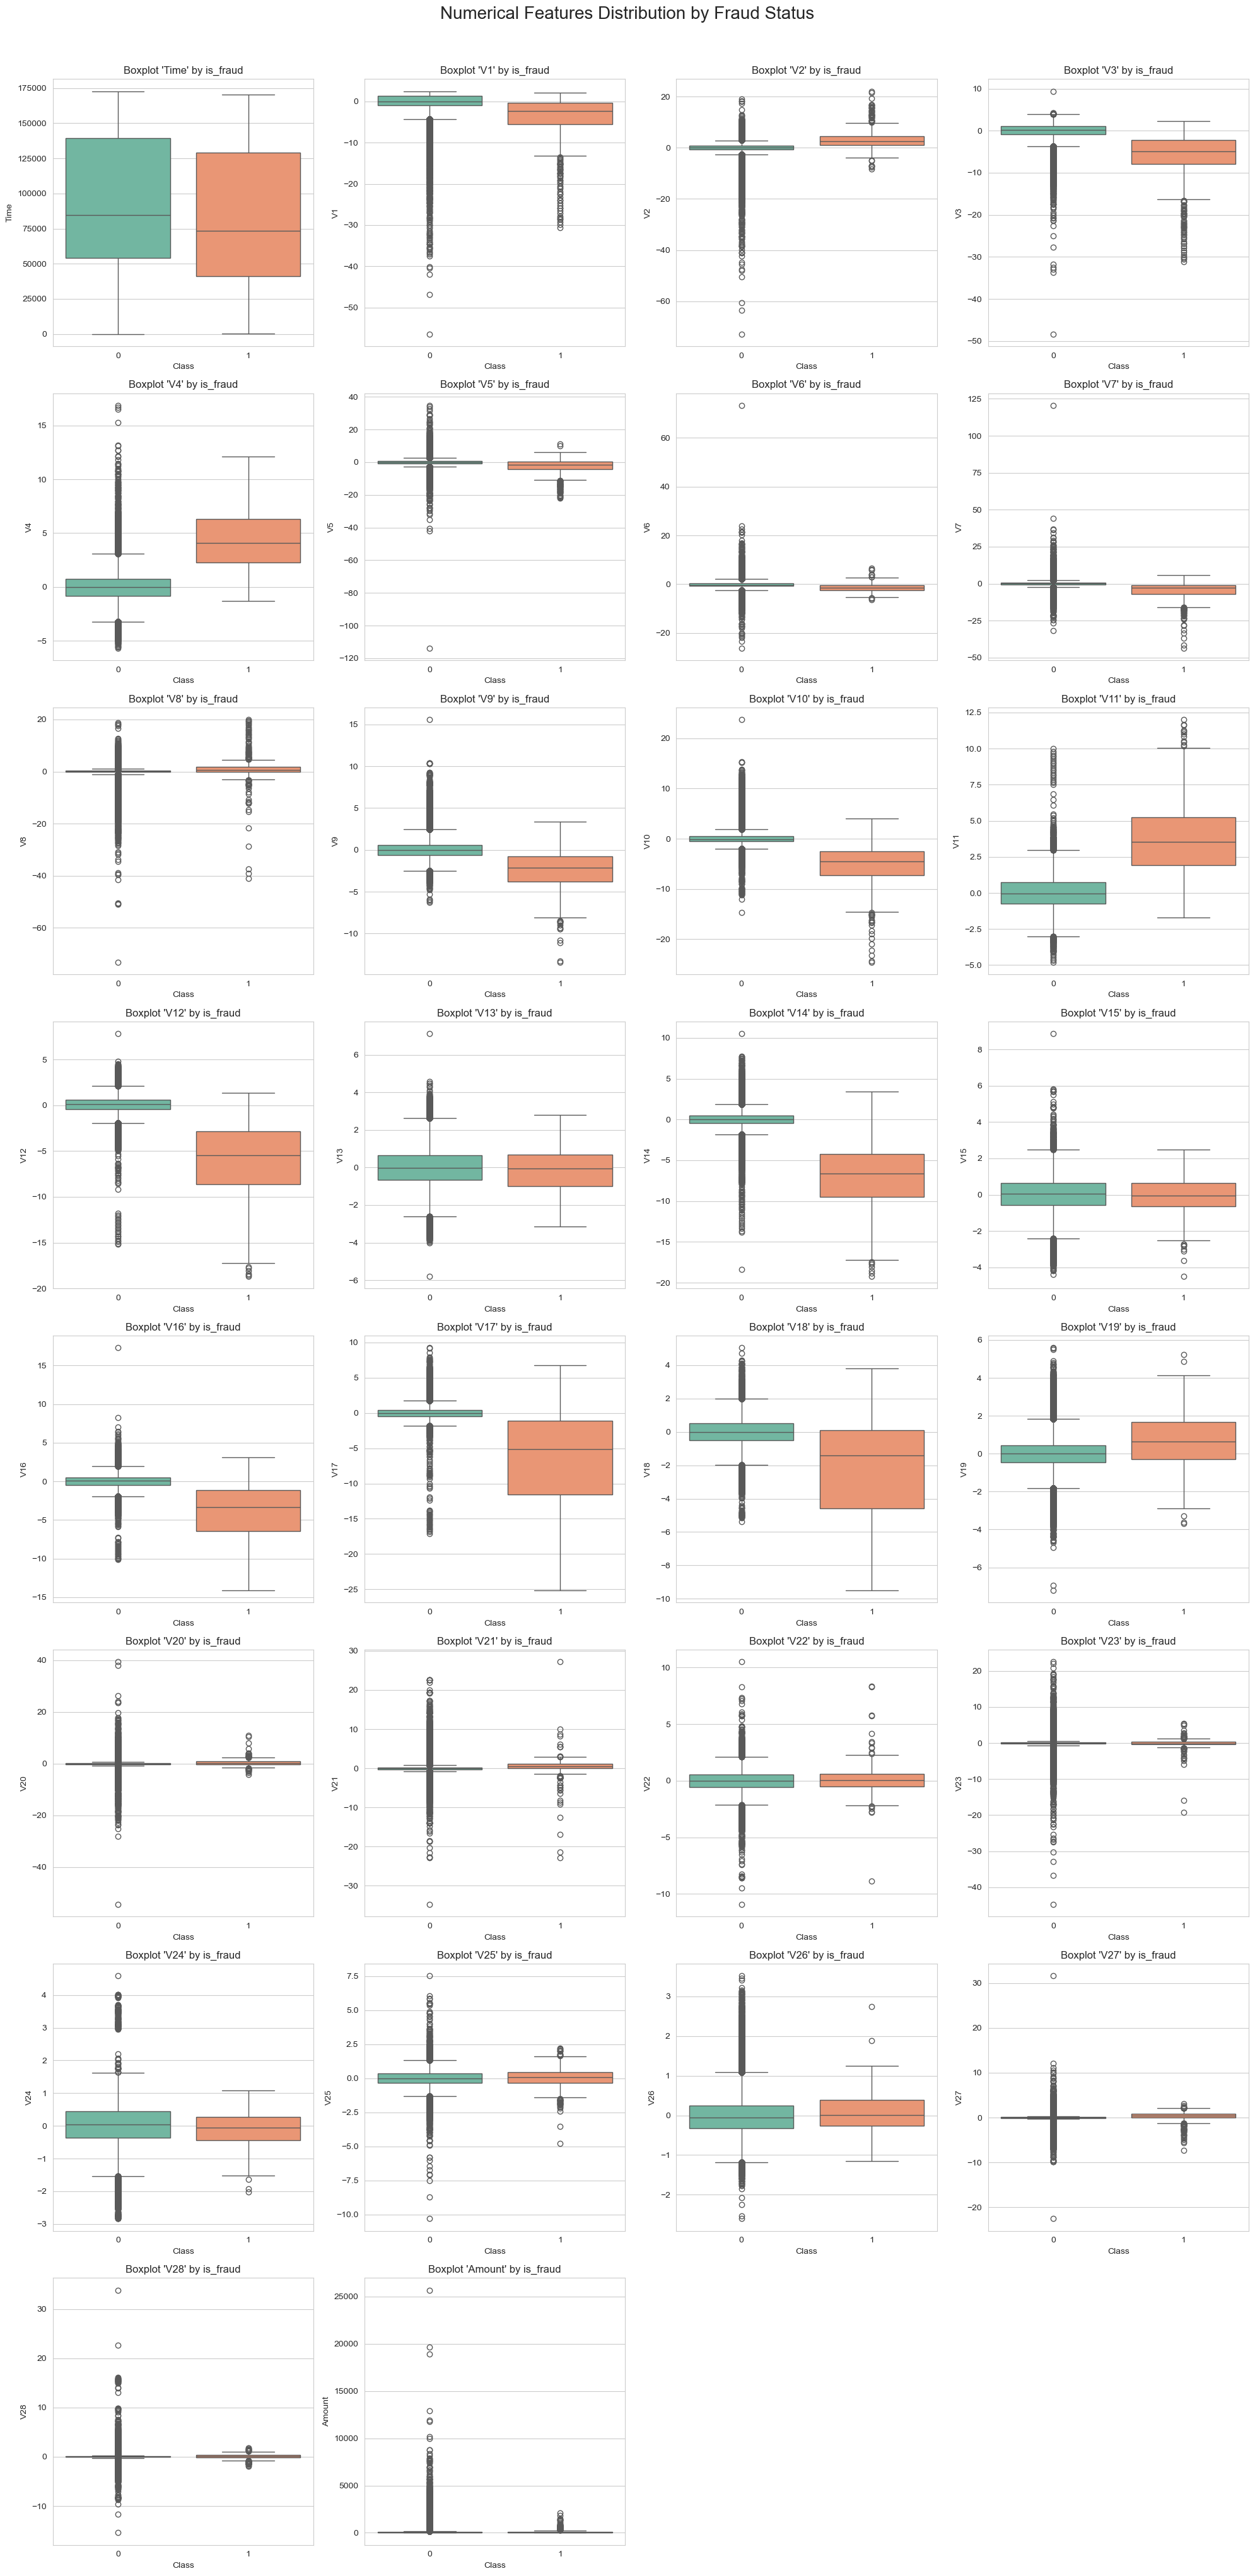

In [33]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes_flat = axes.flatten()

exclude_cols = ['Class']

plot_index = 0
for cols in df_ncols:
    if cols in exclude_cols :
        continue

    if plot_index >= len(axes_flat):
        break
    ax = axes_flat[plot_index]
    sns.boxplot(data=df_cleaned, x='Class', y=cols, ax=ax, palette='Set2', hue='Class', legend=False)
    ax.set_title(f"Boxplot '{cols}' by is_fraud")

    if cols == 'amt':
        ax.set_ylim(0, 1750)
    elif cols == 'city_pop':
        ax.set_ylim(0, 100000)
    plot_index += 1
    
for j in range(plot_index, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
fig.suptitle('Numerical Features Distribution by Fraud Status', fontsize=20, y=1.02)
plt.show()

**Observation:** Features V28, V27, and Amount exhibit significant outlier rates exceeding 10%. Furthermore, boxplots reveal distinct distributional shifts between the two target classes for features such as V4, V11, and V12, indicating strong potential for class classification.

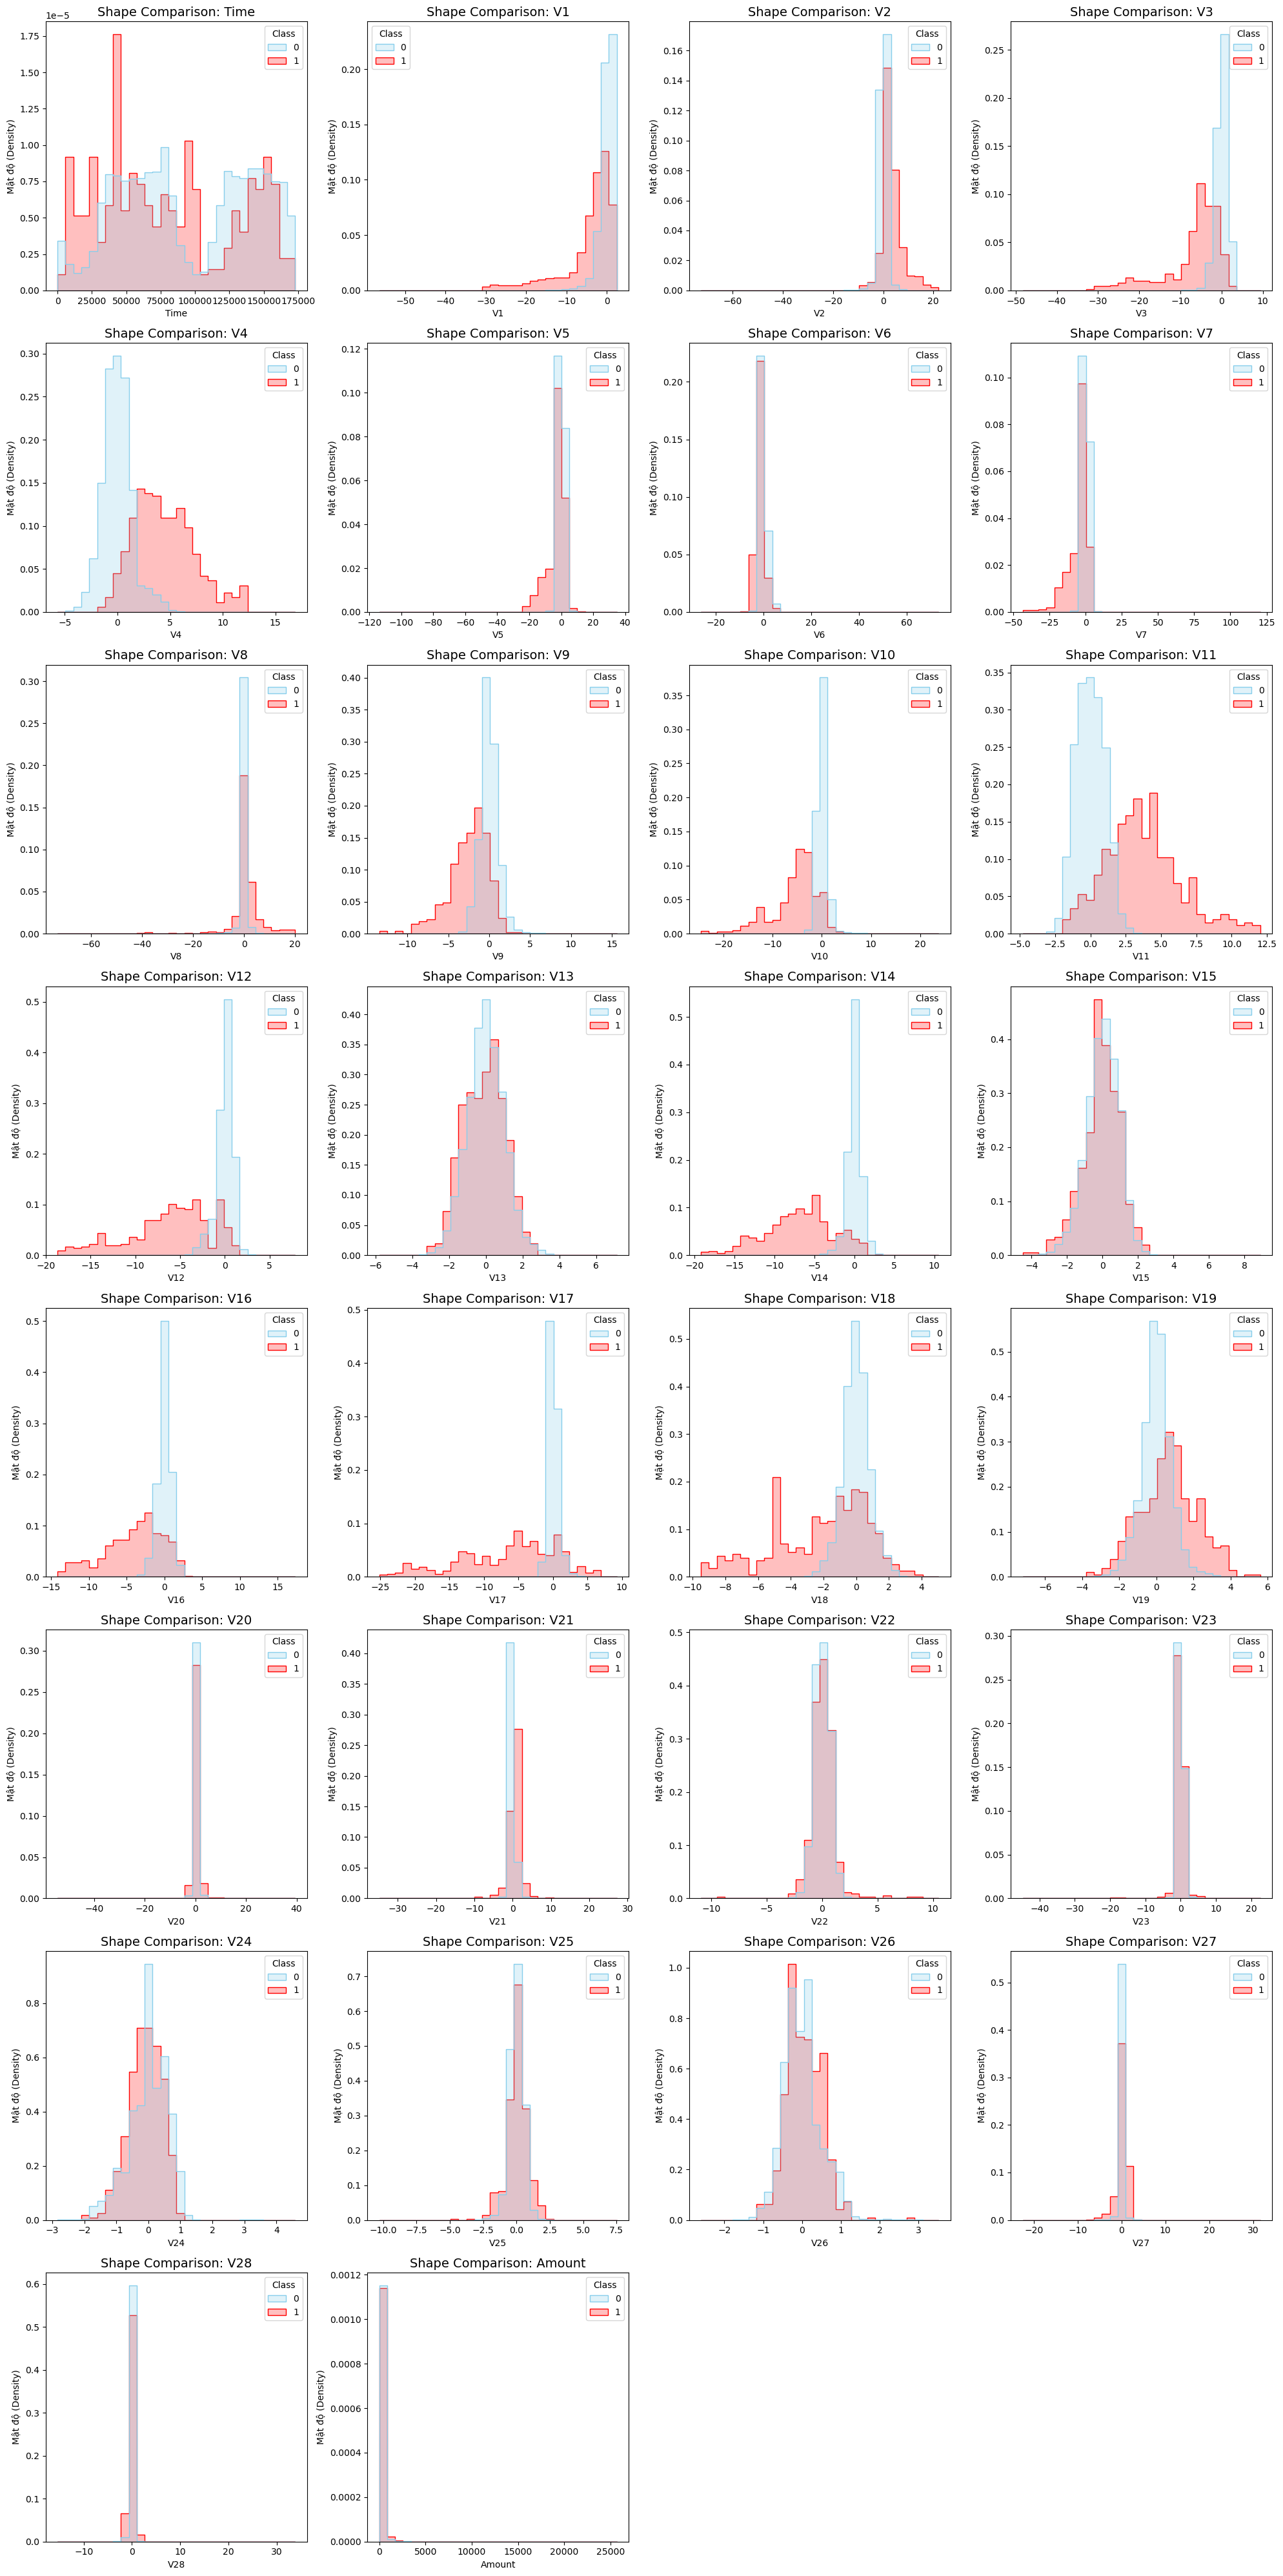

In [20]:
exclude_cols = ['Class']
plot_columns = [c for c in df_ncols if c not in exclude_cols]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes_flat = axes.flatten()

for i, col in enumerate(plot_columns):
    if i >= len(axes_flat):
        break
    
    ax = axes_flat[i]
    sns.histplot(
        data=df_cleaned, 
        x=col, 
        hue='Class', 
        kde=False,            
        element="step",      
        stat="density",      
        common_norm=False,    
        palette={0: 'skyblue', 1: 'red'}, 
        ax=ax,  # Vẽ vào đúng trục hiện tại
        bins=30
    )
    ax.set_title(f'Shape Comparison: {col}', fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Mật độ (Density)')

# Xóa các ô trống nếu số lượng cột ít hơn số ô subplot đã tạo
for j in range(len(plot_columns), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

**Hour was extracted from the time column to capture repeatable temporal patterns**

In [5]:
df_cleaned['Hour'] = (df_cleaned['Time'] // 3600) % 24

In [22]:
df_cleaned['Hour'].describe()

count    283726.000000
mean         14.045646
std           5.834817
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64

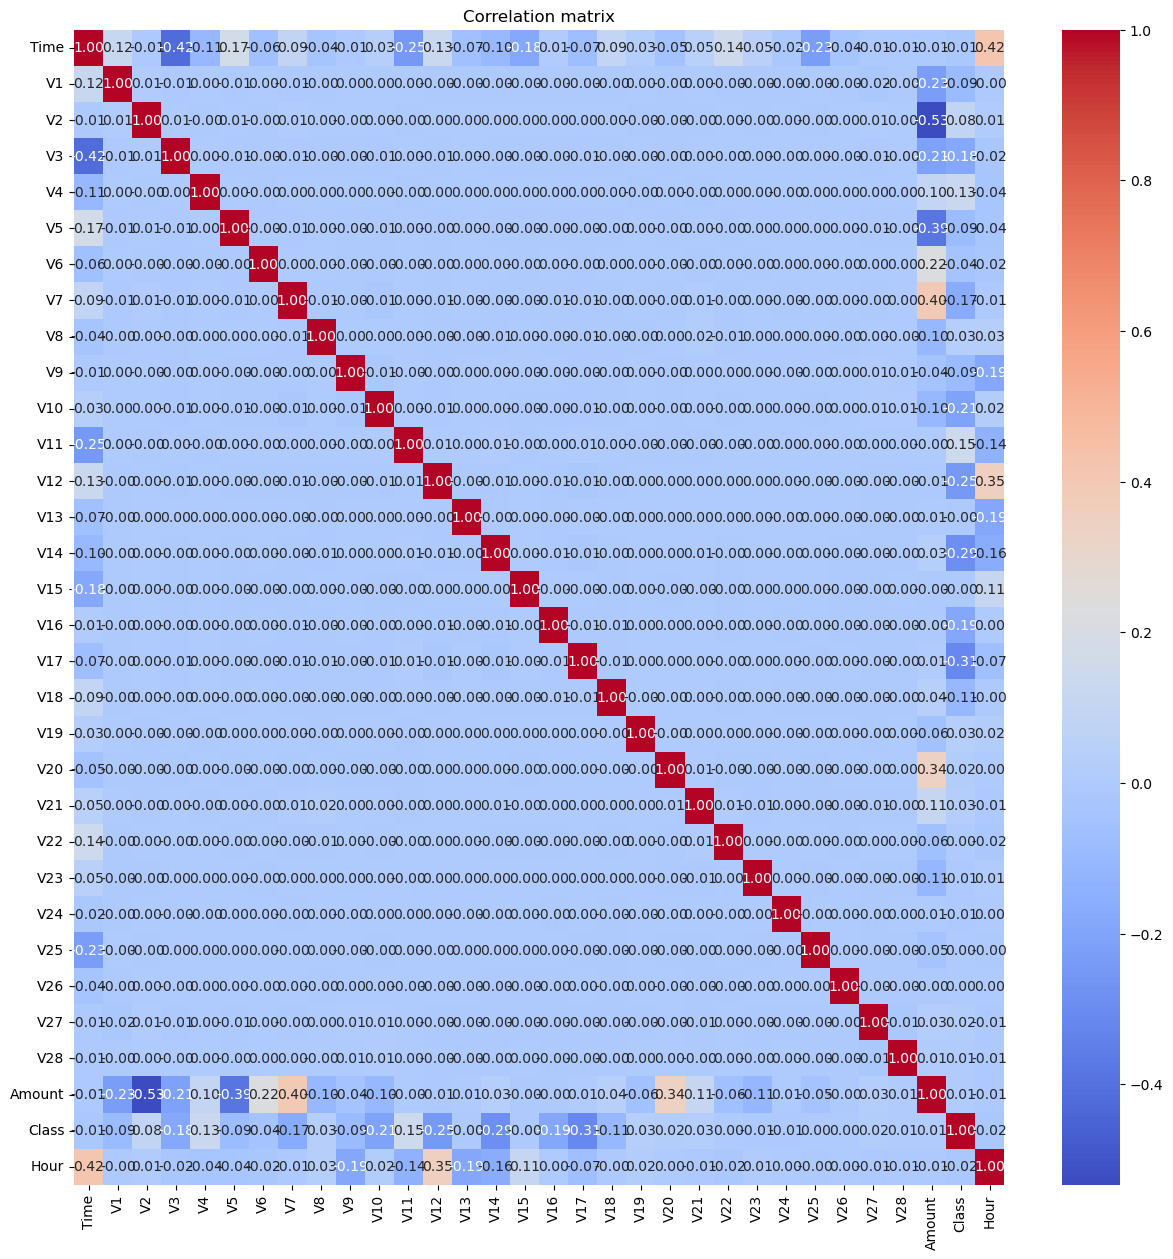

In [6]:
plt.figure(figsize=(15, 15)) 
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix')
plt.show()

**Observation:** no strong multicollinearity among the PCA-derived features or the Amount variable, which is expected due to the orthogonal nature of PCA components. The use of PCA limits feature interpretability but reduces dimensionality and noise.

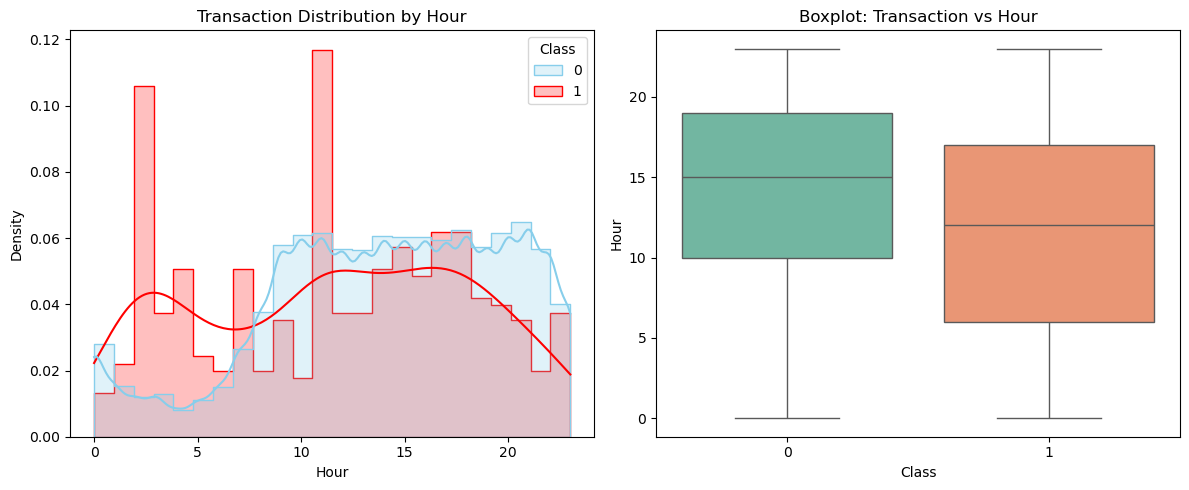

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

# Histogram / Density
sns.histplot(
    data=df_cleaned, 
    x='Hour', 
    hue='Class', 
    kde=True,          
    element="step",      
    stat="density",     
    common_norm=False,   
    palette={0: 'skyblue', 1: 'red'}, 
    ax=axes[0],          
    bins=24              
)
axes[0].set_title('Transaction Distribution by Hour')

# Biểu đồ Boxplot
sns.boxplot(
    data=df_cleaned, 
    x='Class', y='Hour', 
    ax=axes[1],          
    palette='Set2', 
    hue='Class', 
    legend=False
)
axes[1].set_title('Boxplot: Transaction vs Hour')

plt.tight_layout()
plt.show()

**To ensure model reliability, features exhibiting significant skewness or a high sensitivity to outliers must be identified and addressed. Applying effective transformation and scaling methods is essential to normalize distributions and prevent extreme values from biasing the model's performance.**

In [8]:
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
skewness = df_cleaned[numeric_cols].apply(lambda x: skew(x.dropna()))
skewness = skewness.sort_values(ascending=False)

high_skew_cols = skewness[abs(skewness) > 0.75].index
print(high_skew_cols)

Index(['Class', 'Amount', 'V28', 'V7', 'V21', 'V6', 'V10', 'V27', 'V16', 'V14',
       'V20', 'V3', 'V12', 'V5', 'V1', 'V17', 'V2', 'V23', 'V8'],
      dtype='object')


In [9]:
df_skewness = skewness.reset_index()
df_skewness.columns = ['Variable', 'Skewness']
df_skewness = df_skewness.sort_values(by='Skewness', ascending=False)
print(df_skewness.head())

  Variable   Skewness
0    Class  24.430416
1   Amount  16.978714
2      V28  11.555054
3       V7   2.890256
4      V21   2.820018


In [16]:
df_outlier = status_df.reset_index()
df_outlier.columns = ['Variable', 'Outlier_rate']

In [17]:
df_combined = pd.merge(df_outlier, df_skewness, on='Variable')
df_combined['Abs_Skewness'] = df_combined['Skewness'].abs()

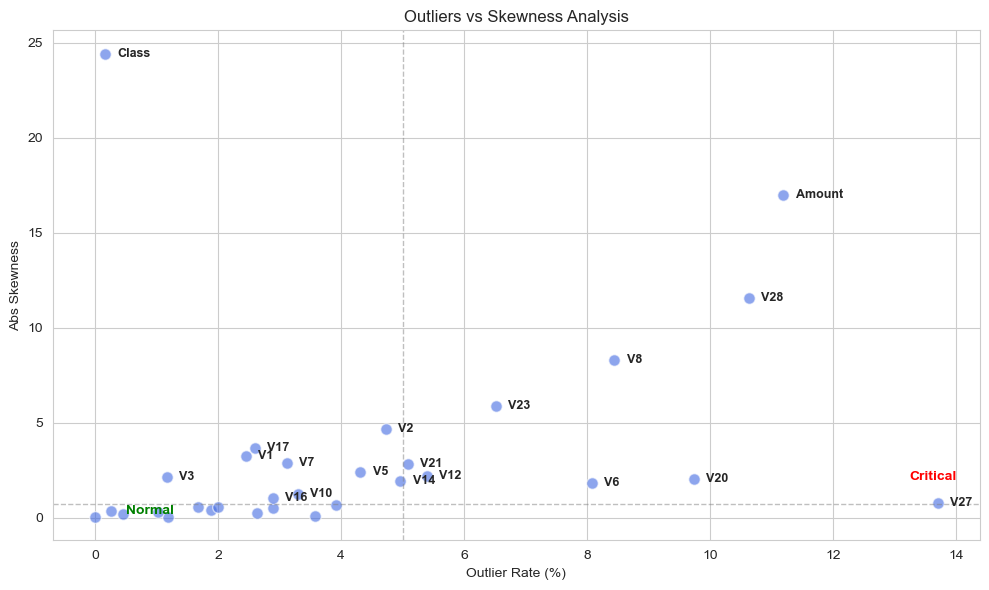

In [42]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.scatter(df_combined['Outlier_rate'], df_combined['Abs_Skewness'], 
            color='royalblue', s=70, alpha=0.6, edgecolors='white')

# 2. Đường phân tách đơn giản
plt.axhline(y=0.75, color='gray', linestyle='--', lw=1, alpha=0.5)
plt.axvline(x=5, color='gray', linestyle='--', lw=1, alpha=0.5)

for i in range(len(df_combined)):
    x = df_combined['Outlier_rate'].iloc[i]
    y = df_combined['Abs_Skewness'].iloc[i]
    label = df_combined['Variable'].iloc[i]
    
    if y > 1 or x > 8:
        plt.text(x + 0.2, y, label, fontsize=9, fontweight='bold', va='center')

plt.text(14, 2, 'Critical', color='red', fontweight='bold', ha='right')
plt.text(0.5, 0.2, 'Normal', color='green', fontweight='bold')

plt.title('Outliers vs Skewness Analysis')
plt.xlabel('Outlier Rate (%)')
plt.ylabel('Abs Skewness')
plt.tight_layout()
plt.show()

**Based on this scatter plot, different transformation and scaling method will be exercuted in specific group**

# TEST AND TRAIN SET SPLIT  
In fraud detection, maintaining the temporal order of transactions is critical. Spending patterns evolve over time, and a model must be evaluated on its ability to predict future fraud based on past data.
- Sorting: The dataset is first ordered chronologically using the unix_time column.
- Split Strategy: A Time-Series Split is executed instead of a random shuffle.
- Data Integrity: shuffle=False is strictly applied during the split. This ensures that the training set strictly precedes the test set in time, preventing temporal leakage (where the model accidentally "sees" future patterns during training).

In [18]:
df_cleaned = df_cleaned.sort_values('Time')

In [19]:
X = df_cleaned.drop(columns=['Class','Time'])
y = df_cleaned['Class']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, shuffle=False, random_state = 42)
X_train.shape

(226980, 30)

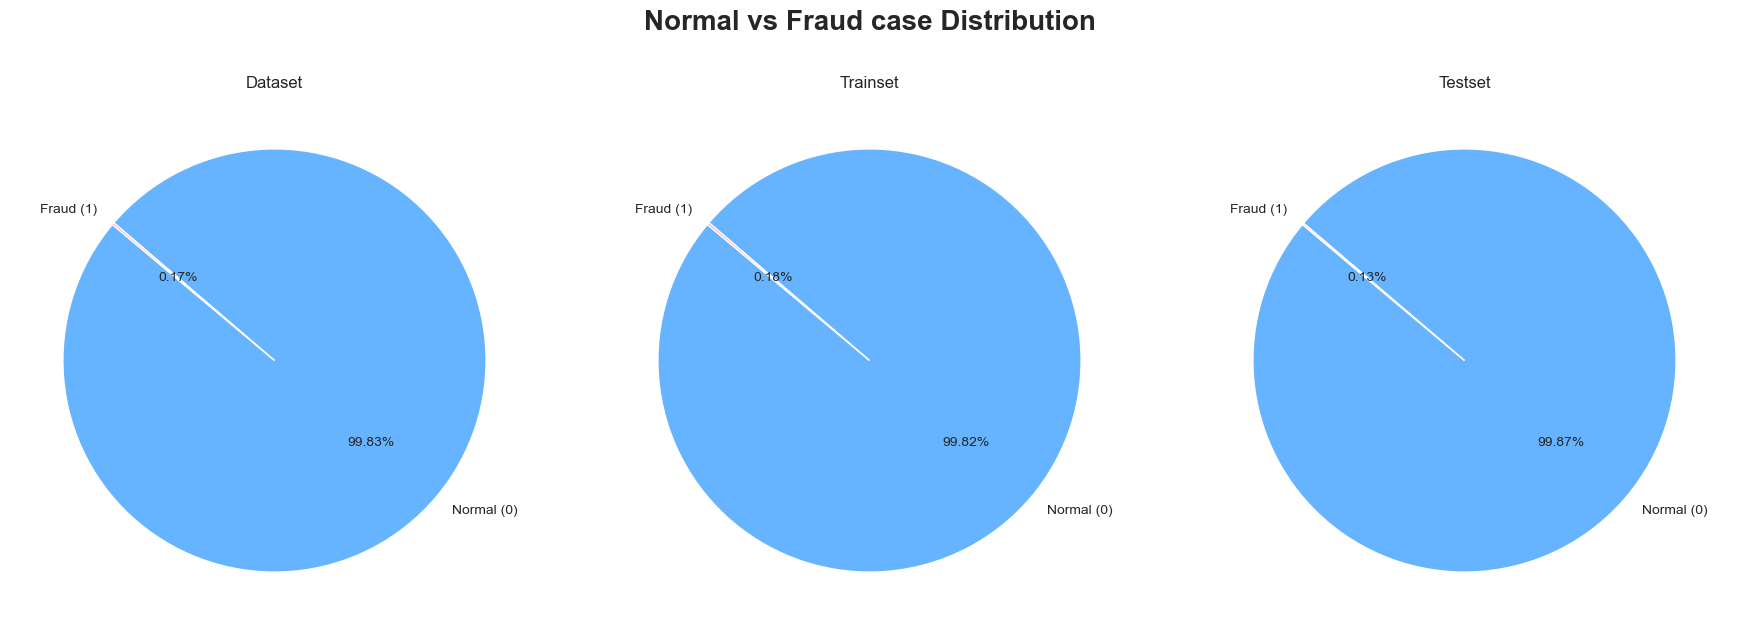

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fraud_counts = df_cleaned['Class'].value_counts()
fraud_counts_train = y_train.value_counts()
fraud_counts_test = y_test.value_counts()

labels = ['Normal (0)', 'Fraud (1)']
colors = ['#66b3ff', '#ff9999'] 

axes[0].pie(fraud_counts, 
        labels=labels, 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=colors)
axes[0].set_title('Dataset')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(fraud_counts_train, 
        labels=labels, 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=colors)

axes[1].set_title('Trainset')
axes[1].tick_params(axis='x', rotation=45)

axes[2].pie(fraud_counts_test, 
        labels=labels, 
        autopct='%1.2f%%', 
        startangle=140, 
        colors=colors)

axes[2].set_title('Testset')
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle('Normal vs Fraud case Distribution', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Observation:** The fraud-to-total transaction ratio remained consistent across both the training and test sets. This indicates that despite using a time-series split, the underlying distribution of fraudulent cases remains stable over time, ensuring that the model is trained and evaluated on a consistent fraud pattern.

# DATA PREPARATION

In [26]:
num_log_robust_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('robust', RobustScaler())
])

In [21]:
X_train.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour'],
      dtype='object')

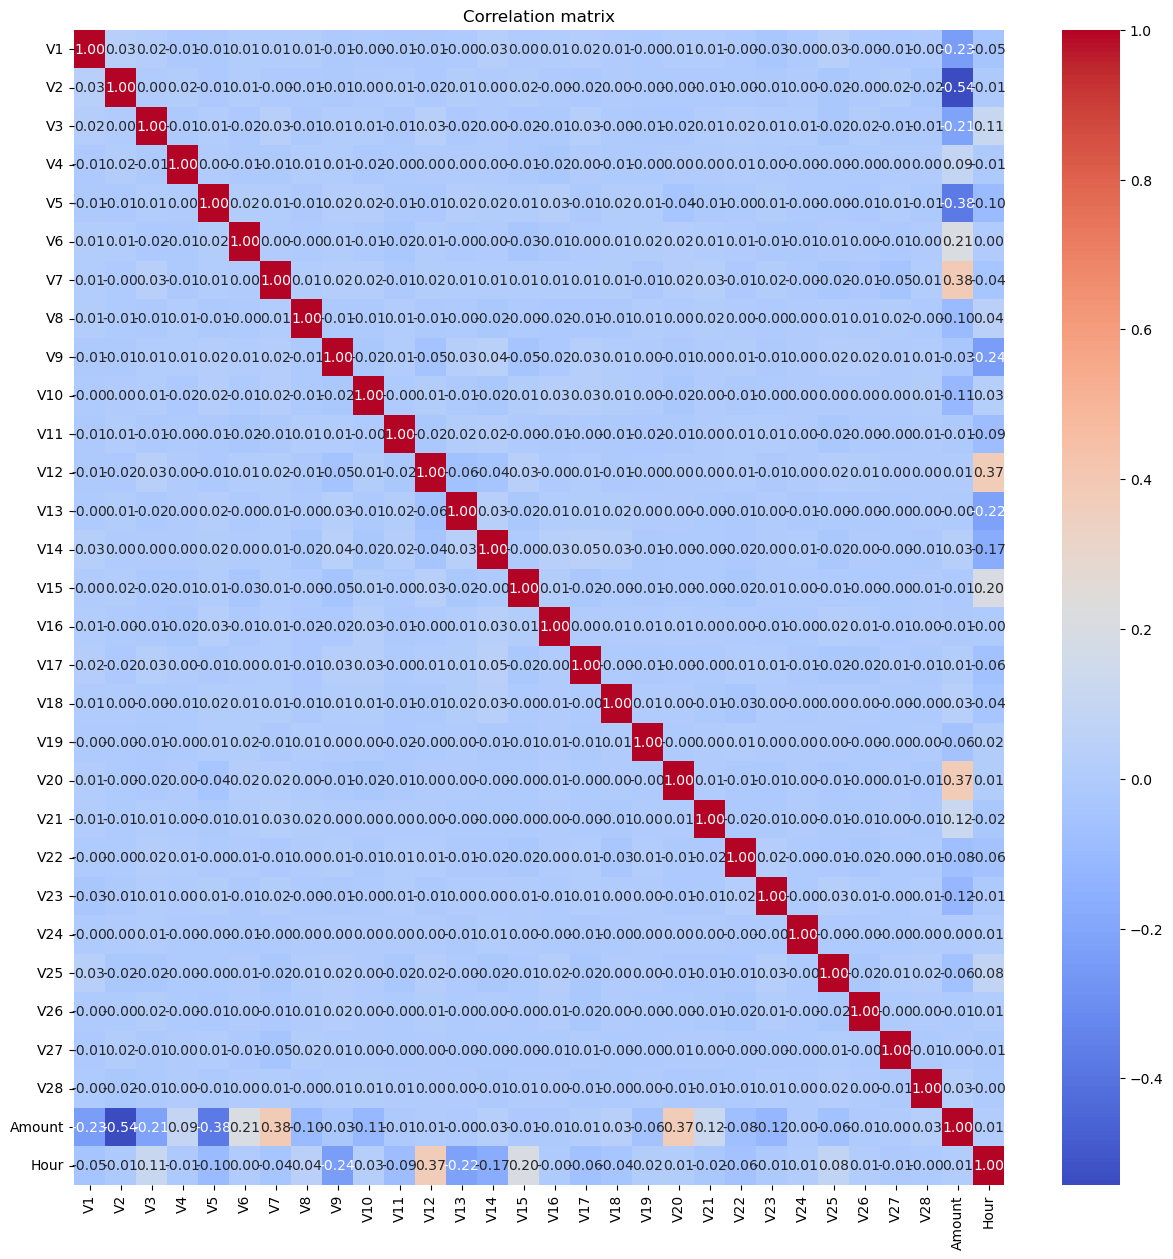

In [22]:
plt.figure(figsize=(15, 15)) 
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix')
plt.show()

To address the diverse distributions of features, a multi-stage ColumnTransformer was implemented to apply tailored scaling and transformation strategies:
- Logarithmic + Robust Scaling (Amount): Given its extreme right-skewness and wide range, the Amount feature underwent a log transformation followed by robust scaling to stabilize variance and minimize outlier impact.
- Robust Scaling (high_skew_cols): Features with significant skewness were processed using RobustScaler, which uses the interquartile range (IQR) to ensure outliers do not distort the feature scaling.
- Standard Scaling (low_skew_cols): Features with near-normal distributions were normalized using StandardScaler (centering to mean 0 and unit variance).

In [36]:
numeric_cols_train = X_train.select_dtypes(include=['number']).columns

log_to_scale = ['Amount']
features_to_scale = [col for col in high_skew_cols if col not in ['Class','Amount']]
low_skew_cols = [col for col in numeric_cols_train if col not in high_skew_cols and col != 'Class']

preprocessor = ColumnTransformer(
    transformers=[
        ('log', num_log_robust_pipe, log_to_scale),
        ('rob', RobustScaler(), features_to_scale),
        ('std', StandardScaler(), low_skew_cols)
    ],
    remainder='drop'
)

In [50]:
X_train_final = preprocessor.fit_transform(X_train, y_train)
X_train_final[1]

array([-0.77296641, -0.00960334, -0.08122101, -0.48469378,  0.13419555,
       -0.07529247, -0.07957558,  0.40024327, -0.23636193, -0.05214159,
       -0.11942814,  0.89060855,  0.14205943,  0.5594358 , -0.07930566,
        0.14469796,  0.42290056,  0.09884172,  0.28859911, -0.22840442,
        1.48932011,  0.46272884,  0.62675016, -0.19257896, -0.16880017,
       -0.8705855 , -0.56290952,  0.25453491,  0.25268955, -2.22710367])

**Observation:** After completing the transformation and scaling phase, the dataset contains 30 independent variables. To optimize model performance and maintain interpretability, a Feature Selection step is executed using a Random Forest approach. 

In [51]:
# try to use Random Forest with class_weight='balanced' to add the weight to imbalanced class 
rf_model_weight = RandomForestClassifier(
    n_jobs=-1,        
    random_state=42 ,
    class_weight='balanced'
)

rf_model_weight.fit(X_train_final,y_train)

importances_2 = rf_model_weight.feature_importances_

In [52]:
feature_names = log_to_scale + features_to_scale + low_skew_cols
fi_df_2 = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_2
}).sort_values(by='importance', ascending=False)
fi_df_2

,feature,importance
8,V14,0.188003
18,V4,0.102232
11,V12,0.097418
5,V10,0.094253
14,V17,0.086428
20,V11,0.069860
7,V16,0.066686
2,V7,0.035594
10,V3,0.035101
15,V2,0.025665


**Observation:** From this feature importance list, we can tell that the importance is splitted to all PCA features, which is because of the way PCA work - extract the helpful information from the orginal features, compress it into smaller number of uncorrelated components, wwhich means every PCA variables carry at least some helpful infor to help the model. However, we will still test the more compact model after drop some less importance feature

# MODELING - LOGISTIC REGRESSION

**LR on selected features**

In [29]:
numeric_cols_train = X_train.select_dtypes(include=['number']).columns
selected_cols = ['V14','V4','V12','V10','V17','V11','V16','V7','V3', 'V2','V1','V18','V9','Amount','V20','V21','V19','V5']
log_to_scale = [col for col in ['Amount'] if col in selected_cols]

features_to_scale = [col for col in high_skew_cols if col in selected_cols and col not in ['Class', 'Amount']]

low_skew_cols = [col for col in numeric_cols_train if col in selected_cols and col not in high_skew_cols and col != 'Class']

preprocessor_2 = ColumnTransformer(
    transformers=[
        ('log', num_log_robust_pipe, log_to_scale),
        ('rob', RobustScaler(), features_to_scale),
        ('std', StandardScaler(), low_skew_cols)
    ],
    remainder='drop')

In [30]:
X_train_selected = X_train[selected_cols].copy()
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}
ratios = [0.2, 0.3, 0.5]
tscv = TimeSeriesSplit(n_splits=3)

print(f"Start running Logistic Classification on {X_train_selected.shape[1]} features...")
print("-" * 50)

for ratio in ratios:
    lr_pipe_s = Pipeline([
        ('prep', preprocessor_2),
        ('under', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    results = cross_validate(lr_pipe_s, X_train_selected, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
    print(f"SMOTE Ratio {ratio}:")
    print(f"  > Mean F1 Score: {results['test_f1'].mean():.4f}")
    print(f"  > Mean PR-AUC:   {results['test_pr_auc'].mean():.4f}")
    print("-" * 30)

Start running Logistic Classification on 18 features...
--------------------------------------------------
SMOTE Ratio 0.2:
  > Mean F1 Score: 0.0823
  > Mean PR-AUC:   0.6758
------------------------------
SMOTE Ratio 0.3:
  > Mean F1 Score: 0.0858
  > Mean PR-AUC:   0.6637
------------------------------
SMOTE Ratio 0.5:
  > Mean F1 Score: 0.0834
  > Mean PR-AUC:   0.6738
------------------------------


In [31]:
print(f"Start running Logistic Classification without hybrid sampling on {X_train_selected.shape[1]} features...")
print("-" * 50)

lr_pipe_s_2 = Pipeline([
    ('prep', preprocessor_2),
    ('lr', LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000, random_state=42))
])
results_2 = cross_validate(lr_pipe_s_2, X_train_selected, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
print(f"  > Mean F1 Score: {results_2['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results_2['test_pr_auc'].mean():.4f}")
print("-" * 30)

Start running Logistic Classification without hybrid sampling on 18 features...
--------------------------------------------------
  > Mean F1 Score: 0.1031
  > Mean PR-AUC:   0.7060
------------------------------


In [33]:
print(f"Start running Logistic Classification without undersampling on {X_train_selected.shape[1]} features...")
print("-" * 50)

for ratio in ratios:
    lr_pipe_s_3 = Pipeline([
        ('prep', preprocessor_2),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    results_3 = cross_validate(lr_pipe_s_3, X_train_selected, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
    print(f"SMOTE Ratio {ratio}:")
    print(f"  > Mean F1 Score: {results_3['test_f1'].mean():.4f}")
    print(f"  > Mean PR-AUC:   {results_3['test_pr_auc'].mean():.4f}")
    print("-" * 30)

Start running Logistic Classification without undersampling on 18 features...
--------------------------------------------------
SMOTE Ratio 0.2:
  > Mean F1 Score: 0.0898
  > Mean PR-AUC:   0.7035
------------------------------
SMOTE Ratio 0.3:
  > Mean F1 Score: 0.0904
  > Mean PR-AUC:   0.7035
------------------------------
SMOTE Ratio 0.5:
  > Mean F1 Score: 0.0904
  > Mean PR-AUC:   0.7041
------------------------------


**LR on entire trainset features**

In [53]:
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}
ratios = [0.2, 0.3, 0.5]
tscv = TimeSeriesSplit(n_splits=3)

print(f"Start running Logistic Classification on {X_train.shape[1]} features...")
print("-" * 50)

for ratio in ratios:
    lr_pipe = Pipeline([
        ('prep', preprocessor),
        ('under', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    results = cross_validate(lr_pipe, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
    print(f"SMOTE Ratio {ratio}:")
    print(f"  > Mean F1 Score: {results['test_f1'].mean():.4f}")
    print(f"  > Mean PR-AUC:   {results['test_pr_auc'].mean():.4f}")
    print("-" * 30)

Start running Logistic Classification on 30 features...
--------------------------------------------------
SMOTE Ratio 0.2:
  > Mean F1 Score: 0.0536
  > Mean PR-AUC:   0.6193
------------------------------
SMOTE Ratio 0.3:
  > Mean F1 Score: 0.0599
  > Mean PR-AUC:   0.6063
------------------------------
SMOTE Ratio 0.5:
  > Mean F1 Score: 0.0610
  > Mean PR-AUC:   0.6305
------------------------------


In [54]:
print(f"Start running Logistic Classification without hybrid sampling on {X_train.shape[1]} features...")
print("-" * 50)

lr_pipe_2 = Pipeline([
    ('prep', preprocessor),
    ('lr', LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000, random_state=42))
])
results_2 = cross_validate(lr_pipe_2, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
print(f"  > Mean F1 Score: {results_2['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results_2['test_pr_auc'].mean():.4f}")
print("-" * 30)

Start running Logistic Classification without hybrid sampling on 30 features...
--------------------------------------------------
  > Mean F1 Score: 0.0718
  > Mean PR-AUC:   0.7381
------------------------------


In [55]:
print(f"Start running Logistic Classification without undersampling on {X_train.shape[1]} features...")
print("-" * 50)

for ratio in ratios:
    lr_pipe_3 = Pipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    results_3 = cross_validate(lr_pipe_3, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
    print(f"SMOTE Ratio {ratio}:")
    print(f"  > Mean F1 Score: {results_3['test_f1'].mean():.4f}")
    print(f"  > Mean PR-AUC:   {results_3['test_pr_auc'].mean():.4f}")
    print("-" * 30)

Start running Logistic Classification without undersampling on 30 features...
--------------------------------------------------
SMOTE Ratio 0.2:
  > Mean F1 Score: 0.0714
  > Mean PR-AUC:   0.7521
------------------------------
SMOTE Ratio 0.3:
  > Mean F1 Score: 0.0685
  > Mean PR-AUC:   0.7466
------------------------------
SMOTE Ratio 0.5:
  > Mean F1 Score: 0.0702
  > Mean PR-AUC:   0.7432
------------------------------


**Tuning threshold**

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)

In [34]:
all_y_val_3 = []
all_y_probs_3 = []

for train_index, val_index in tscv.split(X_train):
    X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
    
    lr_pipe_s_2.fit(X_t, y_t)
    
    probs = lr_pipe_s_2.predict_proba(X_v)[:, 1]
    
    all_y_val_3.extend(y_v)
    all_y_probs_3.extend(probs)

all_y_val_3 = np.array(all_y_val_3)
all_y_probs_3 = np.array(all_y_probs_3)

precision_3, recall_3, thresholds_3 = precision_recall_curve(all_y_val_3, all_y_probs_3)
f1_scores_3 = 2 * (precision_3 * recall_3) / (precision_3 + recall_3 + 1e-10)

best_threshold_3 = thresholds_3[np.argmax(f1_scores_3)]

print(f"Best threshold: {best_threshold_3:.4f}")
print(f"Highest F1 Score: {np.max(f1_scores_3):.4f}")

Best threshold: 0.9987
Highest F1 Score: 0.7346


**Observation:** By this step, we can see, LR model now is too strict, the model try to find out all the fraud transaction (Recall high) while the precision rate is extremely low, which meant to find out all the fraud transaction, model mark hundred legitimate ones as fraud, which is not suitable for bank as they relized on the customer experience as well. Even when we use different method to deal with the imbalanced of the dataset. The model work best at 0.9999 threshold, so we will apply those threshold on the test set

# RESULT + EVALUATION - LOGISTIC REGRESSION

In [49]:
lr_pipe_s_2.fit(X_train, y_train)
test_preds_s = lr_pipe_s_2.predict(X_test)

print("--- Result at default threshold ---")
print(classification_report(y_test, test_preds_s))

--- Result at default threshold ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56672
           1       0.04      0.88      0.08        74

    accuracy                           0.97     56746
   macro avg       0.52      0.93      0.53     56746
weighted avg       1.00      0.97      0.99     56746



In [50]:
y_test_probs_lr = lr_pipe_s_2.predict_proba(X_test)[:, 1]
y_test_pred_lr = (y_test_probs_lr >= best_threshold_3).astype(int)

print(classification_report(y_test, y_test_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56672
           1       0.73      0.65      0.69        74

    accuracy                           1.00     56746
   macro avg       0.86      0.82      0.84     56746
weighted avg       1.00      1.00      1.00     56746



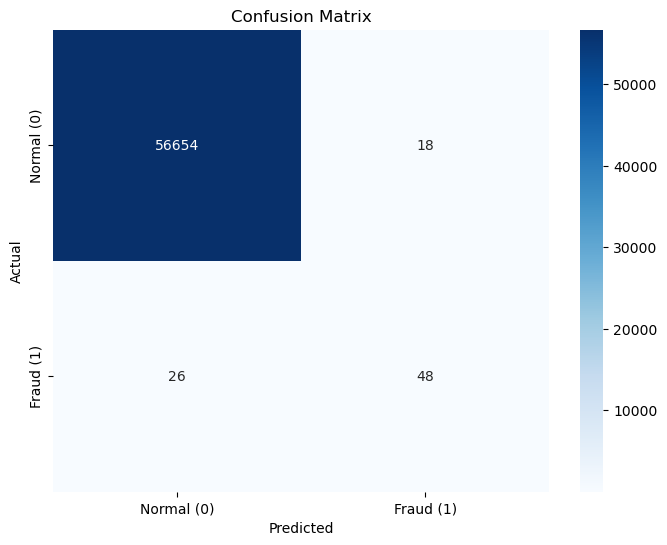

In [51]:
cm = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()

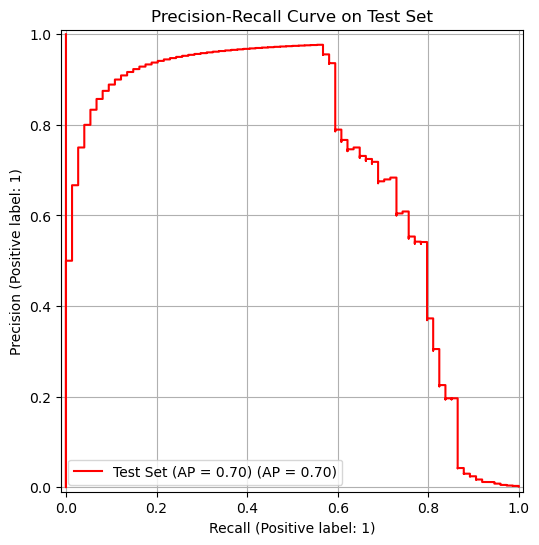

In [53]:
ap_test_lr = average_precision_score(y_test, y_test_probs_lr)

fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs_lr, name=f"Test Set (AP = {ap_test_lr:.2f})", ax=ax, color='red'
)
ax.set_title("Precision-Recall Curve on Test Set")
ax.grid(True)
plt.show()

# MODELING - LOGISTIC REGRESSION

In [62]:
scoring = {'f1': 'f1', 'pr_auc': 'average_precision'}

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,        
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

results = cross_validate(rf_pipe, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=1)

print(f"Random Forest Result:")
print(f"  > Mean F1 Score: {results['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results['test_pr_auc'].mean():.4f}")

Random Forest Result:
  > Mean F1 Score: 0.7977
  > Mean PR-AUC:   0.7898


In [63]:
rf_pipe_s = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,        
        class_weight='balanced_subsample', 
        random_state=42, 
        n_jobs=1         
    ))
])

results_s = cross_validate(rf_pipe_s, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=1)

print(f"Random Forest Result:")
print(f"  > Mean F1 Score: {results_s['test_f1'].mean():.4f}")
print(f"  > Mean PR-AUC:   {results_s['test_pr_auc'].mean():.4f}")

Random Forest Result:
  > Mean F1 Score: 0.8019
  > Mean PR-AUC:   0.7913


**Observation:** Result between class_weight='balanced' and 'balanced_subsample' turn out no significant performance diffent. Therefore, the standard 'balanced' approach was adopted for its computational efficiency and stability.

In [69]:
param_distributions = { 
    'rf__max_depth': [10, 20, 30, None], 
    'rf__min_samples_leaf': [4, 10], 
    'rf__min_samples_split': [2, 5, 10], 
    'rf__n_estimators': [100] 
}
scoring_metrics = { 'F1': 'f1', 'PR_AUC': 'average_precision' }


random_search = RandomizedSearchCV( 
    estimator=rf_pipe_s, 
    param_distributions=param_distributions,
    n_iter=5, 
    cv=tscv, 
    scoring=scoring_metrics,
    refit='F1', 
    n_jobs=1, 
    verbose=2,
    random_state=42 
)

random_search.fit(X_train, y_train)

results_df = pd.DataFrame(random_search.cv_results_)

important_columns = [ 'param_rf__max_depth', 'param_rf__min_samples_leaf', 'mean_test_F1', 'mean_test_PR_AUC' ] 
print(results_df[important_columns].sort_values(by='mean_test_F1', ascending=False))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END rf__max_depth=20, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=100; total time= 1.1min
[CV] END rf__max_depth=20, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=100; total time= 2.9min
[CV] END rf__max_depth=20, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=100; total time= 4.9min
[CV] END rf__max_depth=30, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time=  49.9s
[CV] END rf__max_depth=30, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time= 2.3min
[CV] END rf__max_depth=30, rf__min_samples_leaf=10, rf__min_samples_split=5, rf__n_estimators=100; total time= 4.2min
[CV] END rf__max_depth=10, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=100; total time=  51.5s
[CV] END rf__max_depth=10, rf__min_samples_leaf=4, rf__min_samples_split=2, rf__n_estimators=100; total time= 2.0mi

In [72]:
# check the score of the whole training set by using the best model
best_model = random_search.best_estimator_
train_f1 = f1_score(y_train, best_model.predict(X_train))
print(f"F1 Train: {train_f1:.4f}")
print(f"F1 Test (Validation): {random_search.best_score_:.4f}")

F1 Train: 0.9268
F1 Test (Validation): 0.8112


In [73]:
rf_pipe_1 = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=20,
        min_samples_leaf = 10,
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [74]:
rf_pipe_1.fit(X_train, y_train)
y_train_pred_1 = rf_pipe_1.predict(X_train)

In [75]:
train_f1_1 = f1_score(y_train, y_train_pred_1)
print(f"F1 Train: {train_f1_1:.4f}")

F1 Train: 0.9279


**Observation:** both two highest result configurations indicate overfitting occurrence, which drove to the second random search with the limited constraint

In [80]:
param_distributions = { 
    'rf__max_depth': [10, 12, 15], 
    'rf__min_samples_leaf': [10, 50, 100], 
    'rf__min_samples_split': [5, 10], 
    'rf__n_estimators': [100] 
}
scoring_metrics = { 'F1': 'f1', 'PR_AUC': 'average_precision' }


random_search_2 = RandomizedSearchCV( 
    estimator=rf_pipe_s, 
    param_distributions=param_distributions,
    n_iter=5, 
    cv=tscv, 
    scoring=scoring_metrics,
    refit='F1', 
    n_jobs=1, 
    verbose=2,
    return_train_score = True,
    random_state=100 
)

random_search_2.fit(X_train, y_train)

results_df_2 = pd.DataFrame(random_search_2.cv_results_)

important_columns = [ 'param_rf__max_depth', 'param_rf__min_samples_leaf', 'mean_test_F1', 'mean_train_F1', 'mean_test_PR_AUC' ] 
print(results_df_2[important_columns].sort_values(by='mean_test_F1', ascending=False))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END rf__max_depth=12, rf__min_samples_leaf=50, rf__min_samples_split=10, rf__n_estimators=100; total time= 1.2min
[CV] END rf__max_depth=12, rf__min_samples_leaf=50, rf__min_samples_split=10, rf__n_estimators=100; total time= 3.6min
[CV] END rf__max_depth=12, rf__min_samples_leaf=50, rf__min_samples_split=10, rf__n_estimators=100; total time= 4.7min
[CV] END rf__max_depth=12, rf__min_samples_leaf=100, rf__min_samples_split=10, rf__n_estimators=100; total time= 1.1min
[CV] END rf__max_depth=12, rf__min_samples_leaf=100, rf__min_samples_split=10, rf__n_estimators=100; total time= 3.0min
[CV] END rf__max_depth=12, rf__min_samples_leaf=100, rf__min_samples_split=10, rf__n_estimators=100; total time= 3.8min
[CV] END rf__max_depth=15, rf__min_samples_leaf=100, rf__min_samples_split=5, rf__n_estimators=100; total time=  53.9s
[CV] END rf__max_depth=15, rf__min_samples_leaf=100, rf__min_samples_split=5, rf__n_estimators=100; tota

In [78]:
# check the score of the whole training set by using the best model
best_model = random_search_2.best_estimator_
train_f1_2 = f1_score(y_train, best_model.predict(X_train))
print(f"F1 Train: {train_f1_2:.4f}")
print(f"F1 Test (Validation): {random_search_2.best_score_:.4f}")

F1 Train: 0.9258
F1 Test (Validation): 0.8112


In [37]:
rf_pipe_2 = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,
        min_samples_leaf = 10,
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [38]:
rf_pipe_2.fit(X_train, y_train)
y_train_pred_2 = rf_pipe_2.predict(X_train)

In [39]:
train_f1_2 = f1_score(y_train, y_train_pred_2)
print(f"F1 Train: {train_f1_2:.4f}")

F1 Train: 0.9040


In [40]:
rf_pipe_3 = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=12,
        min_samples_leaf = 50,
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [41]:
rf_pipe_3.fit(X_train, y_train)
y_train_pred_3 = rf_pipe_3.predict(X_train)

In [42]:
train_f1_3 = f1_score(y_train, y_train_pred_3)
print(f"F1 Train: {train_f1_3:.4f}")

F1 Train: 0.8810


In [43]:
rf_pipe_4 = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=15,
        min_samples_leaf = 100,
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [44]:
rf_pipe_4.fit(X_train, y_train)
y_train_pred_4 = rf_pipe_4.predict(X_train)

In [45]:
train_f1_4 = f1_score(y_train, y_train_pred_4)
print(f"F1 Train: {train_f1_4:.4f}")

F1 Train: 0.8272


In [ ]:
result = pd.concat([results_df, results_df_2])

**Observation:** Despite several attempts to adjust hyperparameters toward a more conservative configuration, the model's performance remained static, with the gap between training and validation scores showing no significant narrowing. This stability suggests that the Random Forest has reached its global performance ceiling on this dataset. Consequently, re_pip_2 was selected as the final candidate for the threshold tuning stage.

Next step, I did the same to RF model intergates with hyrid sampling

In [46]:
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=42)
smote = SMOTE(sampling_strategy=0.1, random_state=42)

rf_pipe_5 = Pipeline([
    ('prep', preprocessor),
    ('undersample', rus), 
    ('smote', smote),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,      
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

In [ ]:
param_distributions = { 
    'rf__max_depth': [10, 12, 15], 
    'rf__min_samples_leaf': [10, 50, 100], 
    'rf__min_samples_split': [5, 10], 
    'rf__n_estimators': [100] 
}
scoring_metrics = { 'F1': 'f1', 'PR_AUC': 'average_precision' }


random_search_3 = RandomizedSearchCV( 
    estimator=rf_pipe_5, 
    param_distributions=param_distributions,
    n_iter=5, 
    cv=tscv, 
    scoring=scoring_metrics,
    refit='F1', 
    n_jobs=1, 
    verbose=2,
    return_train_score = True,
    random_state=100 
)

random_search_3.fit(X_train, y_train)

results_df_3 = pd.DataFrame(random_search_2.cv_results_)

important_columns = [ 'param_rf__max_depth', 'param_rf__min_samples_leaf', 'mean_test_F1', 'mean_train_F1', 'mean_test_PR_AUC' ] 
print(results_df_3[important_columns].sort_values(by='mean_test_F1', ascending=False))

In [48]:
results_df_3 = pd.DataFrame(random_search_3.cv_results_)

important_columns = [ 'param_rf__max_depth', 'param_rf__min_samples_leaf', 'mean_test_F1', 'mean_train_F1', 'mean_test_PR_AUC' ] 
print(results_df_3[important_columns].sort_values(by='mean_test_F1', ascending=False))

   param_rf__max_depth  param_rf__min_samples_leaf  mean_test_F1  \
3                   15                          10      0.714572   
4                   10                          10      0.681591   
0                   12                          50      0.403473   
2                   15                         100      0.237004   
1                   12                         100      0.236352   

   mean_train_F1  mean_test_PR_AUC  
3       0.845208          0.774278  
4       0.793829          0.769351  
0       0.590578          0.770830  
2       0.385751          0.756768  
1       0.384678          0.758230  


In [55]:
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=42)
smote = SMOTE(sampling_strategy=0.1, random_state=42)

rf_pipe_6 = Pipeline([
    ('prep', preprocessor),
    ('undersample', rus), 
    ('smote', smote),
    ('rf', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,      
        class_weight='balanced', 
        random_state=42, 
        n_jobs=1         
    ))
])

**Tuning Threshold** 
re_pipe_2: cost weighted and re_pipe_6 for hybrid sampling + cost weighted

In [54]:
tscv = TimeSeriesSplit(n_splits=3)

all_y_val = []
all_y_probs = []

for train_index, val_index in tscv.split(X_train):
    # Split dataset into train + validation
    X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Training the model on training set
    rf_pipe_2.fit(X_t, y_t)
    
    probs = rf_pipe_2.predict_proba(X_v)[:, 1]
    
    all_y_val.extend(y_v)
    all_y_probs.extend(probs)

all_y_val = np.array(all_y_val)
all_y_probs = np.array(all_y_probs)

precision, recall, thresholds = precision_recall_curve(all_y_val, all_y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Highest F1 Score: {np.max(f1_scores):.4f}")

Best threshold: 0.5948
Highest F1 Score: 0.8109


In [57]:
tscv = TimeSeriesSplit(n_splits=3)

all_y_val_2 = []
all_y_probs_2 = []

for train_index, val_index in tscv.split(X_train):
    # Split dataset into train + validation
    X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Training the model on training set
    rf_pipe_6.fit(X_t, y_t)
    
    probs = rf_pipe_6.predict_proba(X_v)[:, 1]
    
    all_y_val_2.extend(y_v)
    all_y_probs_2.extend(probs)

all_y_val_2 = np.array(all_y_val_2)
all_y_probs_2 = np.array(all_y_probs_2)

precision_2, recall_2, thresholds_2 = precision_recall_curve(all_y_val_2, all_y_probs_2)
f1_scores_2 = 2 * (precision_2 * recall_2) / (precision_2 + recall_2 + 1e-10)

best_threshold_2 = thresholds_2[np.argmax(f1_scores_2)]

print(f"Best threshold: {best_threshold_2:.4f}")
print(f"Highest F1 Score: {np.max(f1_scores_2):.4f}")

Best threshold: 0.6175
Highest F1 Score: 0.7964


# RESULT + EVALUATION - RANDOM FOREST

In [58]:
rf_pipe_2.fit(X_train, y_train)
y_pred = rf_pipe_2.predict(X_test)

print("---RESULT ON TEST SET---")
print(classification_report(y_test, y_pred))

---RESULT ON TEST SET---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56672
           1       0.86      0.76      0.81        74

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [59]:
y_test_probs = rf_pipe_2.predict_proba(X_test)[:, 1]
y_test_pred_custom = (y_test_probs >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56672
           1       0.88      0.72      0.79        74

    accuracy                           1.00     56746
   macro avg       0.94      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746



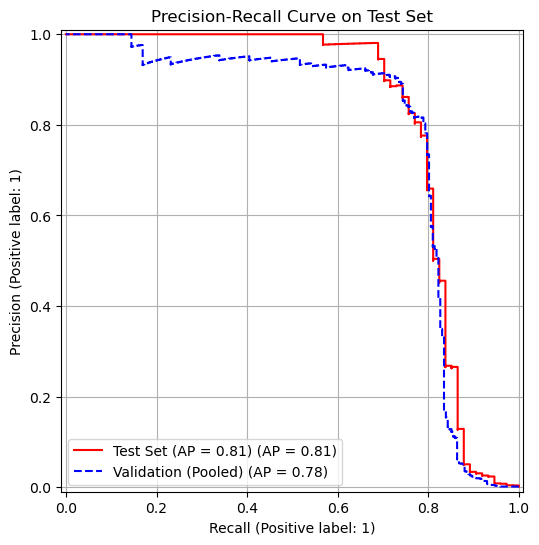

In [60]:
ap_test = average_precision_score(y_test, y_test_probs)

fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs, name=f"Test Set (AP = {ap_test:.2f})", ax=ax, color='red'
)

PrecisionRecallDisplay.from_predictions(all_y_val, all_y_probs, name="Validation (Pooled)", ax=ax, color='blue', linestyle='--')

ax.set_title("Precision-Recall Curve on Test Set")
ax.grid(True)
plt.show()

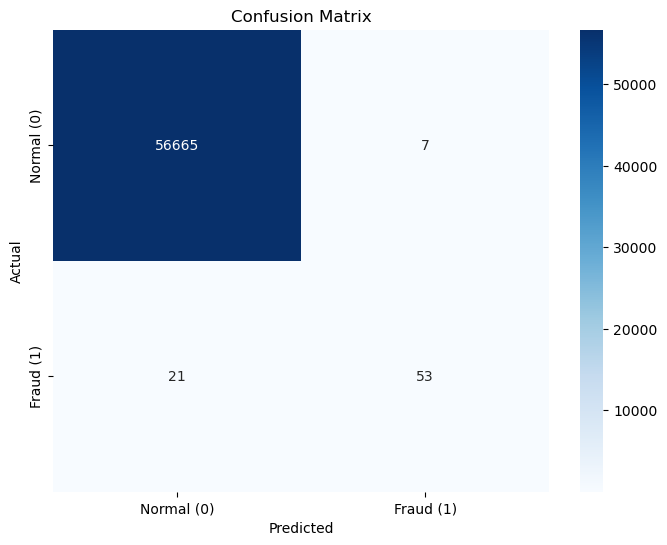

In [66]:
cm = confusion_matrix(y_test, y_test_pred_custom)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()

In [62]:
rf_pipe_6.fit(X_train, y_train)
y_pred_2 = rf_pipe_6.predict(X_test)

print("---RESULT ON TEST SET---")
print(classification_report(y_test, y_pred_2))

---RESULT ON TEST SET---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56672
           1       0.67      0.78      0.72        74

    accuracy                           1.00     56746
   macro avg       0.84      0.89      0.86     56746
weighted avg       1.00      1.00      1.00     56746



In [63]:
y_test_probs_2 = rf_pipe_6.predict_proba(X_test)[:, 1]
y_test_pred_custom_2 = (y_test_probs_2 >= best_threshold_2).astype(int)

print(classification_report(y_test, y_test_pred_custom_2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56672
           1       0.90      0.74      0.81        74

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



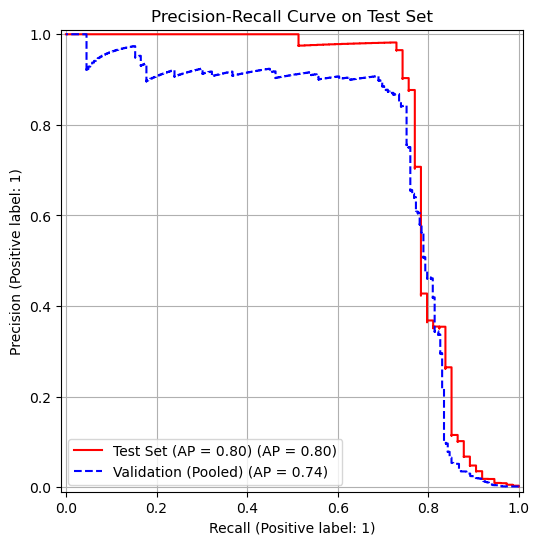

In [64]:
ap_test = average_precision_score(y_test, y_test_probs_2)

fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs_2, name=f"Test Set (AP = {ap_test:.2f})", ax=ax, color='red'
)

PrecisionRecallDisplay.from_predictions(all_y_val_2, all_y_probs_2, name="Validation (Pooled)", ax=ax, color='blue', linestyle='--')

ax.set_title("Precision-Recall Curve on Test Set")
ax.grid(True)
plt.show()

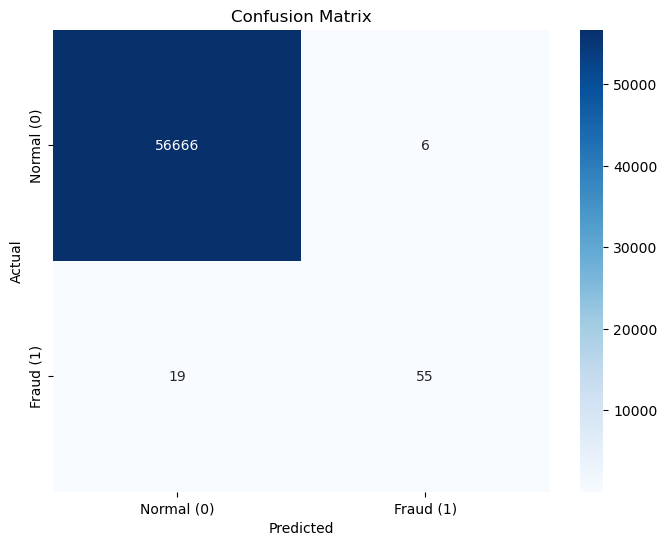

In [69]:
cm = confusion_matrix(y_test, y_test_pred_custom_2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()